 ## <font color="black">Deve-se  predizer o valor médio das casas ocupadas pelo proprietário (medv) por meio das metodologias apresentadas na disciplina (Regressao, Árvores de Regresssão, Bagging e Random Forest). Realize uma comparação entre os modelos por meio de um processo de validação cruzada (Leave One Out) utilizando como medidas o erro quadrático médio e correlação entre os valores preditos e observados. Faça um relatório de maneira organizada discutindo os resultados encontrados.
</font>



## <font color="black">Importando bibliotecas e carregando o conjunto de dados Boston Housing Dataset</font>


In [9]:
import pandas as pd
import numpy as np

dados=pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

dados.head()




,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## <font color="black">Visualizando os nomes das colunas do dataframe</font>


In [10]:


dados.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

## <font color="black">Variáveis independentes e dependentes</font>


In [11]:
# Variáveis independentes


x=dados[['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','b','lstat']]

# Variável dependente

y=dados['medv']

In [12]:
## Lista de bibliotecas

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


# Validalção cruzada (leave-one-out)

loo = LeaveOneOut()

# Listas vazias para guardar as predições de cada modelo
yhat_reg = []
yhat_arvore = []
yhat_bag = []
yhat_rf = []
boston_test=[] #observados

for train_index,test_index in loo.split(x):
  x_train_loo,x_test_loo=x.iloc[train_index],x.iloc[test_index]
  y_train_loo,y_test_loo=y.iloc[train_index],y.iloc[test_index]

  # Guardar o valor real observado (convertendo para escalar)
  boston_test.append(y_test_loo.values[0])

  # REGRESSÃO

  # Adicionando constante no treino e no teste
  x_train_const = sm.add_constant(x_train_loo)
  x_test_const = sm.add_constant(x_test_loo, has_constant='add') # Garante a constante no teste

  mod_reg = sm.OLS(y_train_loo, x_train_const).fit()
  yhat_reg.append(mod_reg.predict(x_test_const).values[0])


  # ÁRVORE DE DECISÃO
  mod_arvore = DecisionTreeRegressor(random_state=42)
  mod_arvore.fit(x_train_loo, y_train_loo)
  yhat_arvore.append(mod_arvore.predict(x_test_loo)[0])

  # BAGGING
  mod_bag = RandomForestRegressor(n_estimators=100,max_features=13,random_state=1)
  mod_bag.fit(x_train_loo, y_train_loo)
  yhat_bag.append(mod_bag.predict(x_test_loo)[0])

  #RANDOM FOREST
  mod_rf = RandomForestRegressor(n_estimators=100,max_features=4,random_state=1)
  mod_rf.fit(x_train_loo, y_train_loo)
  yhat_rf.append(mod_rf.predict(x_test_loo)[0])






In [13]:
## Métricas

# Função auxiliar para calcular as métricas de cada modelo

def calcular_metricas(observados, preditos):
    mse = mean_squared_error(observados, preditos)
    corr, _ = pearsonr(observados, preditos)
    return mse, corr

# Calculando para cada modelo

mse_reg, corr_reg = calcular_metricas(boston_test, yhat_reg)
mse_arvore, corr_arvore = calcular_metricas(boston_test, yhat_arvore)
mse_bag, corr_bag = calcular_metricas(boston_test, yhat_bag)
mse_rf, corr_rf = calcular_metricas(boston_test, yhat_rf)

# Resultados

# Criando um dicionário para transformar em DataFrame
resultados_dict = {
    'Modelo': ['Regressão OLS', 'Árvore de Decisão', 'Bagging', 'Random Forest'],
    'MSE (Erro Quadrático Médio)': [mse_reg, mse_arvore, mse_bag, mse_rf],
    'Correlação (Pearson)': [corr_reg, corr_arvore, corr_bag, corr_rf]
}

df_resultados = pd.DataFrame(resultados_dict)

# Exibindo a tabela final ordenada pelo menor erro (MSE)
print(df_resultados.sort_values(by='MSE (Erro Quadrático Médio)'))

              Modelo  MSE (Erro Quadrático Médio)  Correlação (Pearson)
3      Random Forest                     9.853736              0.942716
2            Bagging                    10.228893              0.937688
1  Árvore de Decisão                    16.394783              0.904629
0      Regressão OLS                    23.725746              0.848027


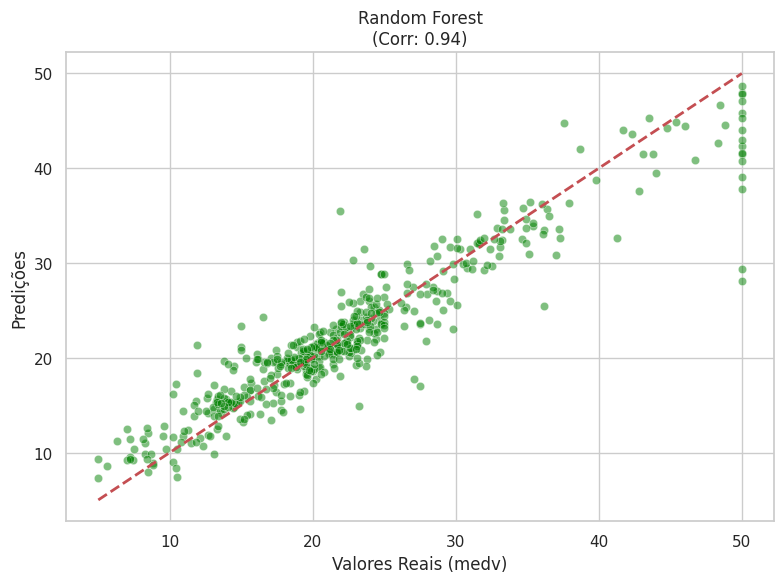

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo do gráfico
plt.figure(figsize=(8,6))



# Random Forest

sns.scatterplot(x=boston_test, y=yhat_rf, alpha=0.5, color='green')
plt.plot([min(boston_test), max(boston_test)], [min(boston_test), max(boston_test)], '--r', linewidth=2)
plt.title(f'Random Forest\n(Corr: {corr_rf:.2f})')
plt.xlabel('Valores Reais (medv)')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()

